In [13]:
import tensorflow as tf
import numpy as np
import  matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dropout,Dense
from tensorflow.keras.optimizers import Adam
import seaborn as sns 
from mlxtend.plotting import plot_decision_regions


In [14]:
x,y=make_moons(100,noise=0.25,random_state=2)

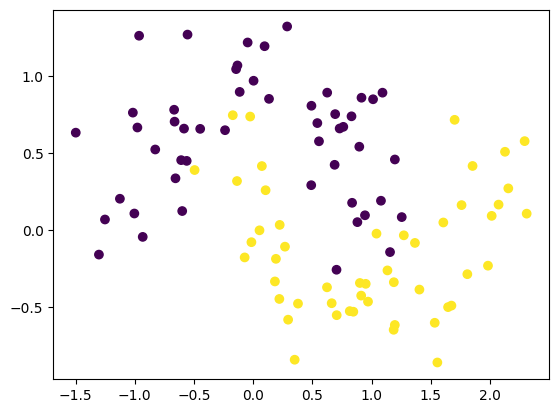

In [15]:
plt.scatter(x[:,0],x[:,1],c=y)
plt.show()

In [16]:
model1=Sequential()
model1.add(Dense(128,input_dim=2,activation='relu'))
model1.add(Dense(128,activation='relu'))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

c:\Users\KhushiAgarwal\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
adam=Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])
history=model1.fit(x,y,epochs=2000,validation_split=0.2)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.4625 - loss: 0.6387 - val_accuracy: 0.9000 - val_loss: 0.3659
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8125 - loss: 0.4373 - val_accuracy: 0.9000 - val_loss: 0.2152
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8250 - loss: 0.3930 - val_accuracy: 0.9000 - val_loss: 0.2298
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8375 - loss: 0.3791 - val_accuracy: 0.9000 - val_loss: 0.2258
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8500 - loss: 0.3719 - val_accuracy: 0.9000 - val_loss: 0.2127
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8500 - loss: 0.3423 - val_accuracy: 0.9000 - val_loss: 0.2369
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8500 - loss: 0.3342 - val_accuracy: 0.9000 - val_loss: 0.2265
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8500 - loss: 0.3180 - val_accuracy: 0.9000 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


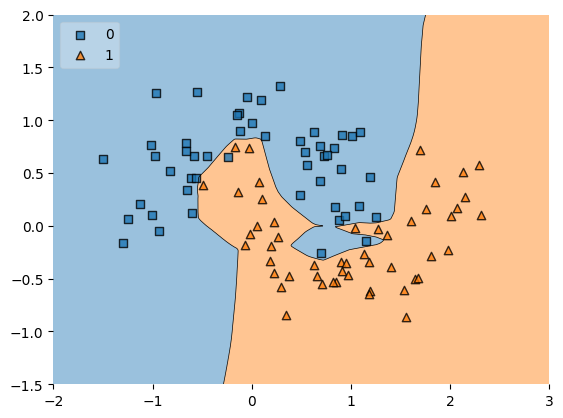

In [18]:
plot_decision_regions(x,y.astype('int'),clf=model1,legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

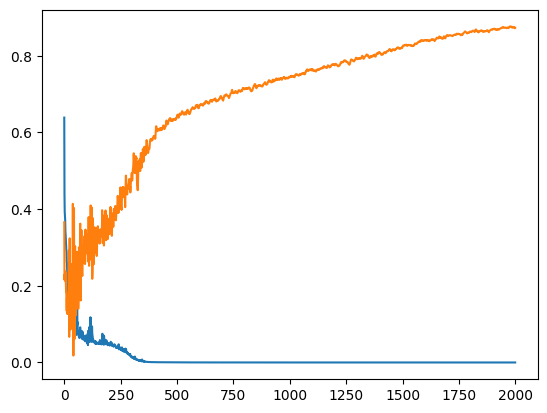

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [20]:
model2=Sequential()

model2.add(Dense(128,input_dim=2,activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.03)))
model2.add(Dense(128,activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.03)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

c:\Users\KhushiAgarwal\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
adam=Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])
history=model2.fit(x,y,epochs=2000,validation_split=0.2)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 331ms/step - accuracy: 0.7000 - loss: 3.9843 - val_accuracy: 0.8500 - val_loss: 2.6709
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7750 - loss: 2.3111 - val_accuracy: 0.9000 - val_loss: 1.4973
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8250 - loss: 1.3289 - val_accuracy: 0.9000 - val_loss: 0.8557
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8125 - loss: 0.8444 - val_accuracy: 0.9000 - val_loss: 0.5955
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8250 - loss: 0.6496 - val_accuracy: 0.9000 - val_loss: 0.5897
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8375 - loss: 0.6294 - val_accuracy: 0.9000 - val_loss: 0.5118
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8250 - loss: 0.6338 - val_accuracy: 0.9000 - val_loss: 0.5309
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8500 - loss: 0.6334 - val_accuracy: 0.9000 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


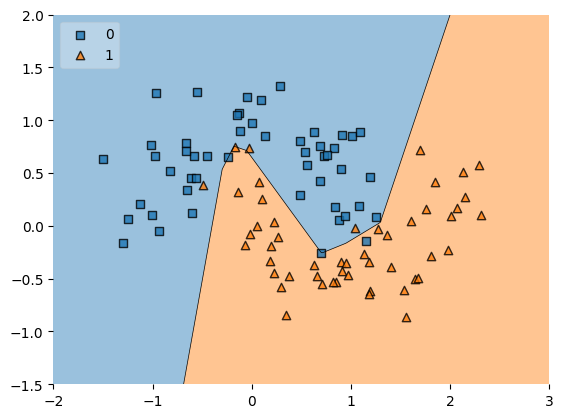

In [22]:
plot_decision_regions(x,y.astype('int'),clf=model2,legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

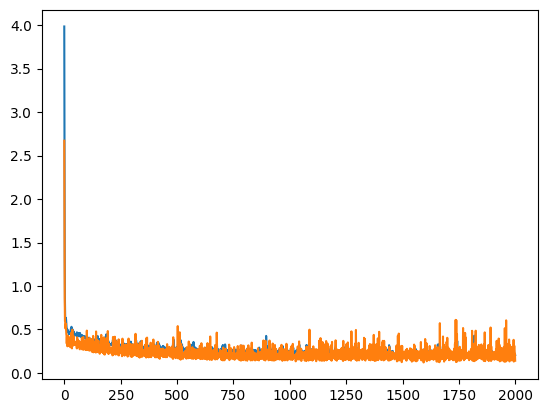

In [23]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [24]:
model1_weight_layer1=model1.get_weights()[0].reshape(256)
model2_weight_layer1=model2.get_weights()[0].reshape(256)

<Axes: >

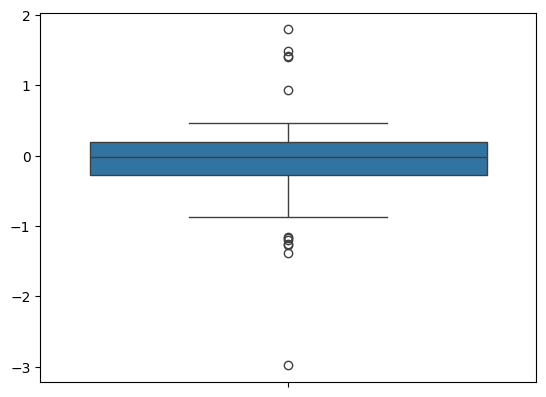

In [25]:
sns.boxplot(model1_weight_layer1)

<Axes: >

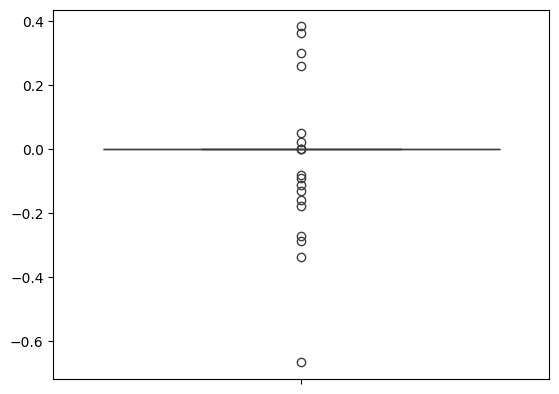

In [26]:
sns.boxplot(model2_weight_layer1)

In [27]:
model1_weight_layer1.max()
model1_weight_layer1.min()

np.float32(-2.9819603)

In [28]:
model2_weight_layer1.max()
model2_weight_layer1.min()

np.float32(-0.66664726)

<Axes: ylabel='Count'>

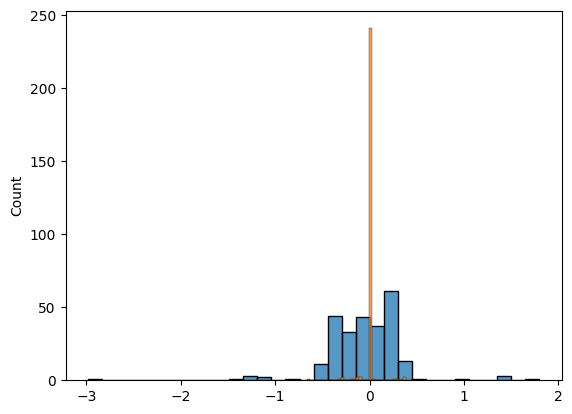

: 

In [ ]:
sns.histplot(model1_weight_layer1)
sns.histplot(model2_weight_layer1)